# Gene expression programs and the copy-number confound

Real tumour expression is more than genotype dosage. iscc's R13 layer builds it from **gene programs**
— co-expressed modules like *proliferation*, *EMT*, *hypoxia* — each a **loading** over genes times a
per-cell **activity** $z$, layered on top of the per-allele copy-number dosage. iscc knows the *true*
loading matrix and the *true* per-cell activities (`program_truth`), ground truth no real dataset has,
so we can ask honestly: **can a factor model recover the programs, and what trips it up?**

The trap is geometric. A **program** is *functional*: its genes are **scattered across the genome**. A
**copy-number segment** is *positional*: contiguous genes co-vary because they share a CN state, not a
function. A factor model sees co-expression either way and can mistake a CNA for a "program" — the
**positional confound** at the heart of `DESIGN_expression.md §4.2`.

**The input is a mixed tumour.** A real scRNA study sees malignant cells *and* microenvironment
(epithelial/stromal), so a factor model must also separate **cell-type identity** from
**within-malignant programs**. We analyse the mixture and use ground truth only to colour and score.

> The full scDEF / cNMF recovery-vs-burden benchmark lives in `validation/validate_programs.py`; here
> we do a self-contained sklearn-NMF version to expose the structure it measures.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import iscc
from iscc.tumor.models import GenotypeTumor
from iscc.data import scRNA

# the R13 program layer config + the positional-clustering diagnostic live in validation/programs_common
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "validation")))
from programs_common import expression_params, positional_clustering, scattered_null
print("iscc from:", iscc.__file__)

# shared spatial config (structure_radius>0 => cancer gland + normal compartment) with programs ON
GENOME    = {"n_segments": 12, "segment_size": 50}
SELECTION = {"prop_driver": 0.2, "prop_dispersal": 0.0, "prop_immune_resistance": 0.0,
             "prop_treatment_resistance": 0.0}
DEME      = {"carrying_capacity": 8, "initial_cancer_cells": 4}
SPATIAL   = {"grid_size": 20, "structure_radius": 5}
CANCER    = {"division_rate": 0.6, "death_rate": 0.03, "max_birth_rate": 0.98,
             "mutation_rate": 1.1, "dispersal_rate": 0.5}
EXPR      = expression_params()      # the R13 program + activity + dosage config
SEED = 3

def cell_types(t):
    gid = t.cell_data["cell_type"]["cell_id"].astype(str).values
    g = t.genotypes
    return np.array([g[x].type if x in g else "?" for x in gid])

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## 1. Grow the tumour and assay the mixture

The programs live in the malignant cells; the microenvironment carries baseline expression and its own
cell-type identity. We assay the mixture with the F3 scRNA model and surface the true per-cell program
activity (`cell_program`, columns = program names) for the malignant cells.

grown gland: 2891 cells  |  malignant 147   normal 2744
6 gene programs: ['proliferation', 'emt', 'hypoxia', 'drug_resistance', 'immune_evasion', 'program_5']
assayed mixture: 297 cells  |  purity 49%


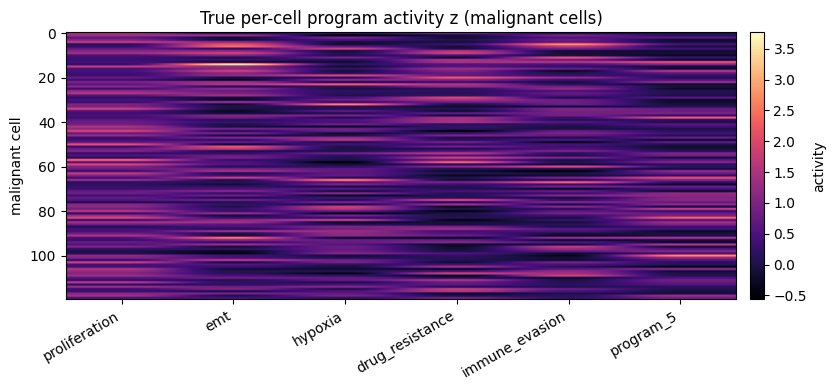

In [2]:
t = GenotypeTumor(seed=SEED, genome_params=GENOME, selection_params=SELECTION,
                  cancer_cell_params=CANCER, deme_params=DEME, spatial_params=SPATIAL,
                  expression_params=EXPR)
t.grow(n_steps=1200, seed=SEED)
t.make_cell_data()
cd = t.cell_data

types = cell_types(t)
idx = np.asarray(cd["cell_exp"].index)
is_cancer = types == "cancer"
pt = t.program_truth
program_names = list(pt["program_names"])
K = len(program_names)
print(f"grown gland: {len(types)} cells  |  malignant {is_cancer.sum()}   normal {(~is_cancer).sum()}")
print(f"{K} gene programs:", program_names)

rng = np.random.default_rng(0)
cancer_cells = list(idx[is_cancer])
normal_cells = list(rng.choice(list(idx[~is_cancer]), size=150, replace=False))
mixture = cancer_cells + normal_cells
mix_pos = np.array([list(idx).index(c) for c in mixture])
is_mal = np.isin(mixture, cancer_cells)
print(f"assayed mixture: {len(mixture)} cells  |  purity {is_mal.mean():.0%}")

rna = scRNA(n_cells=len(mixture), protocol="10x", seed=1).run(cd, cell_subset=mixture)
Z = cd["cell_program"].values         # per-cell activity (cells x K), columns = program_names
fig, ax = plt.subplots(figsize=(8.5, 4))
im = ax.imshow(Z[mix_pos[is_mal]][:120], aspect="auto", cmap="magma")
ax.set_xticks(range(K)); ax.set_xticklabels(program_names, rotation=30, ha="right")
ax.set_ylabel("malignant cell"); ax.set_title("True per-cell program activity z (malignant cells)")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="activity")
plt.tight_layout()

## 2. Programs vary across the gland

Colouring the malignant cells by their **dominant program** (argmax activity) shows the programs are a
real axis of within-tumour heterogeneity, spatially textured across the gland, with the
microenvironment (grey) as the surrounding context a factor model must set apart.

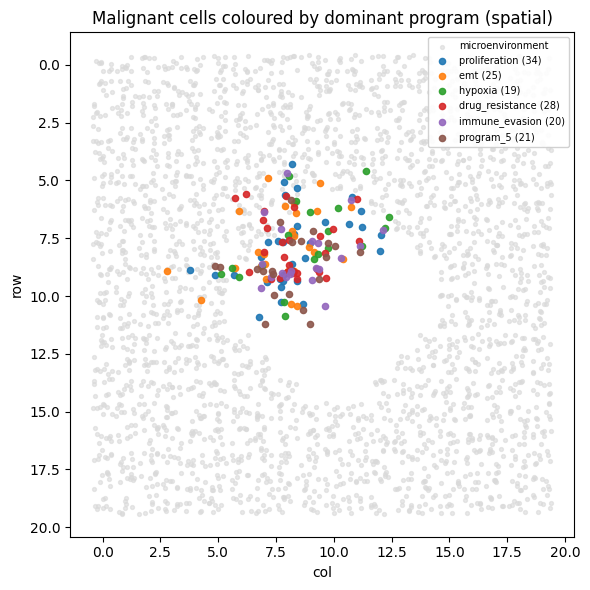

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.42, 0.42, len(crd))
jy = crd["row"].values + jit.uniform(-0.42, 0.42, len(crd))
dom = Z.argmax(1)      # dominant program per cell

fig, ax = plt.subplots(figsize=(7.2, 6))
ax.scatter(jx[~is_cancer], jy[~is_cancer], s=8, c="0.85", alpha=0.6, label="microenvironment")
cmap = plt.get_cmap("tab10")
for k in range(K):
    m = is_cancer & (dom == k)
    if m.sum():
        ax.scatter(jx[m], jy[m], s=20, color=cmap(k), alpha=0.9, label=f"{program_names[k]} ({m.sum()})")
ax.set_aspect("equal"); ax.invert_yaxis()
ax.legend(loc="upper right", fontsize=7, framealpha=0.9)
ax.set_title("Malignant cells coloured by dominant program (spatial)")
ax.set_xlabel("col"); ax.set_ylabel("row")
plt.tight_layout()

## 3. The true loading matrix — programs are scattered

`program_truth["loading"]` is the ground-truth $K \times \text{genes}$ program-by-gene matrix. Each
program loads on genes **spread across the genome**, not one contiguous block — the defining property
of a *functional* module and the thing that will distinguish it from a copy-number segment.

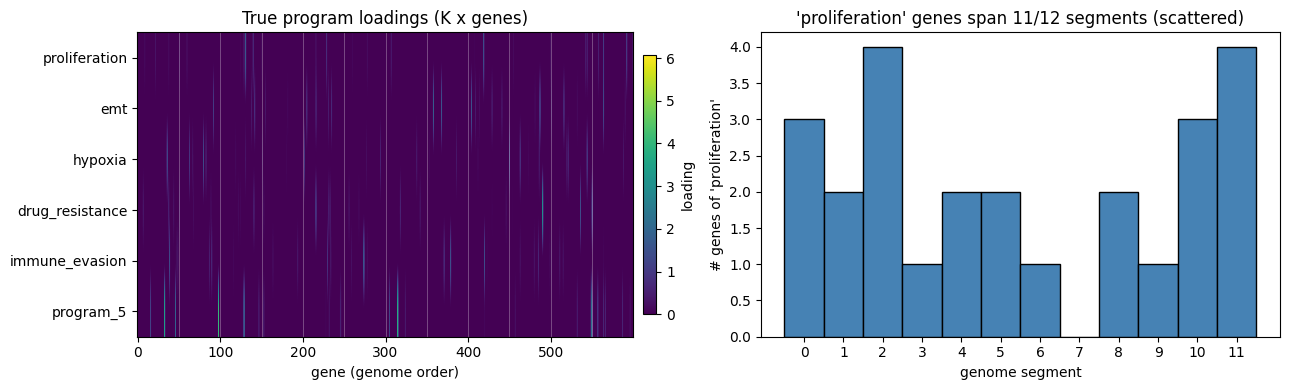

In [4]:
loading = np.asarray(pt["loading"])                # K x genes
sizes = np.asarray(t.selection.segment_sizes)
seg_bounds = np.concatenate([[0], np.cumsum(sizes)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(loading, aspect="auto", cmap="viridis")
axes[0].set_yticks(range(K)); axes[0].set_yticklabels(program_names)
axes[0].set_xlabel("gene (genome order)"); axes[0].set_title("True program loadings (K x genes)")
for b in seg_bounds[1:-1]:
    axes[0].axvline(b, color="w", lw=0.4, alpha=0.5)
plt.colorbar(im, ax=axes[0], fraction=0.025, pad=0.02, label="loading")

# genes of program 0, tallied by segment -> scattered across chromosomes
genes0 = np.asarray(pt["program_genes"][0])
seg_of = np.searchsorted(seg_bounds, genes0, side="right") - 1
axes[1].hist(seg_of, bins=np.arange(t.n_segments + 1) - 0.5, color="steelblue", edgecolor="k")
axes[1].set_xlabel("genome segment"); axes[1].set_ylabel(f"# genes of '{program_names[0]}'")
axes[1].set_title(f"'{program_names[0]}' genes span {len(set(seg_of))}/{t.n_segments} segments (scattered)")
axes[1].set_xticks(range(t.n_segments))
plt.tight_layout()

## 4. The mixture: cell-type identity vs within-malignant programs

Embedding the mixture (PCA of the scRNA counts) shows the two axes a factor model must disentangle. By
**cell type**, the microenvironment forms its own structure, well apart from the malignant cells. Among
the **malignant** cells, the **dominant program** is the finer within-tumour axis. Real data conflates
both — teasing them apart is the realism point.

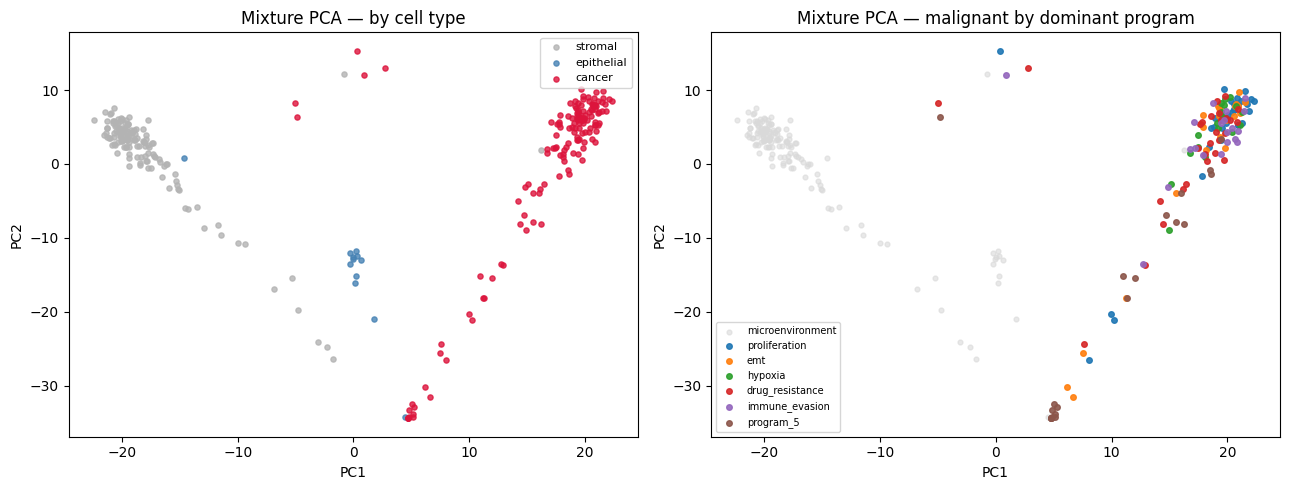

In [5]:
from sklearn.decomposition import PCA

Yv = rna.observed_counts.values.astype(float)
lib = Yv.sum(1, keepdims=True)
Ylog = np.log1p(Yv / np.where(lib > 0, lib, 1.0) * 1e4)
pcs = PCA(n_components=10, random_state=0).fit_transform(Ylog - Ylog.mean(0))
type_of = np.array([types[list(idx).index(c)] for c in mixture])
dom_mix = Z[mix_pos].argmax(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, col in {"stromal": "0.7", "epithelial": "steelblue", "cancer": "crimson"}.items():
    m = type_of == name
    axes[0].scatter(pcs[m, 0], pcs[m, 1], s=14, c=col, alpha=0.8, label=name)
axes[0].legend(fontsize=8); axes[0].set_title("Mixture PCA — by cell type")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(pcs[~is_mal, 0], pcs[~is_mal, 1], s=12, c="0.85", alpha=0.6, label="microenvironment")
cmap = plt.get_cmap("tab10")
for k in range(K):
    m = is_mal & (dom_mix == k)
    if m.sum():
        axes[1].scatter(pcs[m, 0], pcs[m, 1], s=16, color=cmap(k), alpha=0.9, label=program_names[k])
axes[1].legend(fontsize=7); axes[1].set_title("Mixture PCA — malignant by dominant program")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()

## 5. The diagnostic: positional clustering

`positional_clustering` takes a factor's top-loaded genes and returns the largest fraction landing in
any single genome segment. A genuine **program** is scattered, so it sits near the **scattered null**
(what a random gene set of the same size scores — *not* $1/n_\text{segments}$, since the statistic is a
max over segments). A factor that has absorbed a **copy-number segment** is contiguous, so it approaches
**1.0**. This is what separates "found a program" from "found a CNA and called it a program".

scattered null: mean 0.185, q95 0.240
true-program positional clustering: {'proliferation': 0.16, 'emt': 0.2, 'hypoxia': 0.16, 'drug_resistance': 0.12, 'immune_evasion': 0.16, 'program_5': 0.24}
CNA-segment pseudo-factor positional clustering: 1.000


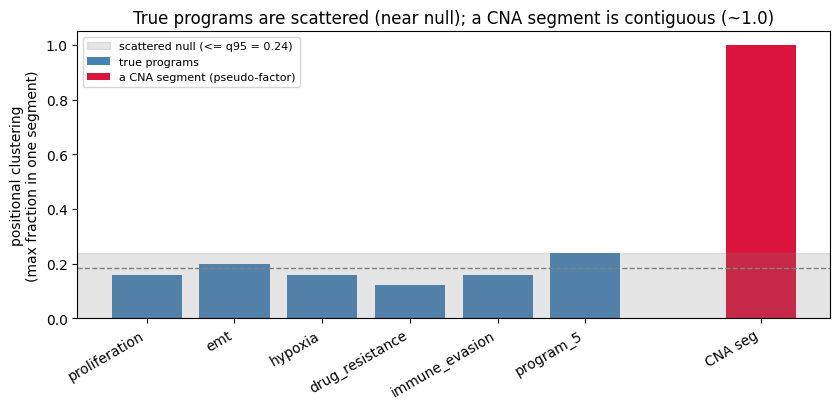

In [6]:
null_mean, null_95 = scattered_null(sizes, top_n=25)
prog_scores = [positional_clustering(loading[k], sizes, top_n=25) for k in range(K)]

# a contiguous copy-number segment, dressed up as a pseudo-factor
cna_factor = np.zeros(int(sizes.sum()))
cna_factor[seg_bounds[3]:seg_bounds[4]] = 1.0
cna_score = positional_clustering(cna_factor, sizes, top_n=25)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(range(K), prog_scores, color="steelblue", label="true programs")
ax.bar([K + 1], [cna_score], color="crimson", label="a CNA segment (pseudo-factor)")
ax.axhspan(0, null_95, color="grey", alpha=0.2, label=f"scattered null (<= q95 = {null_95:.2f})")
ax.axhline(null_mean, color="grey", ls="--", lw=1)
ax.set_xticks(list(range(K)) + [K + 1])
ax.set_xticklabels(program_names + ["CNA seg"], rotation=30, ha="right")
ax.set_ylabel("positional clustering\n(max fraction in one segment)")
ax.set_title("True programs are scattered (near null); a CNA segment is contiguous (~1.0)")
ax.legend(fontsize=8)
plt.tight_layout()
print(f"scattered null: mean {null_mean:.3f}, q95 {null_95:.3f}")
print("true-program positional clustering:", {program_names[k]: round(prog_scores[k], 3) for k in range(K)})
print(f"CNA-segment pseudo-factor positional clustering: {cna_score:.3f}")

## 6. Self-contained recovery: NMF on the mixture

Finally, a from-scratch recovery in the core env: Poisson-sample UMI counts from the mixture's
expression (the fixed-depth scheme `programs_common.counts_anndata` uses, isolating *program structure*
from UMI-model noise), run **sklearn NMF**, and Hungarian-match the factors to the true program
loadings. We give NMF a few **extra** factors so it has room to spend some on **cell-type identity** —
and it does: one factor captures the **malignant-vs-normal axis** (essentially off in the normal cells,
on in the malignant ones) and matches *no* true program, leaving the rest to track the within-malignant
programs. We report the mean loading cosine on the malignant programs (honestly — some programs recover
cleanly, others are hard at this cell count).

NMF with 9 factors (K=6 programs + room for cell-type/extra):
mean loading cosine (malignant programs): 0.567
per-program cosine: {'proliferation': 0.11, 'emt': 0.29, 'hypoxia': 0.84, 'drug_resistance': 0.8, 'immune_evasion': 0.8, 'program_5': 0.55}
cell-type factor = factor 8 (matched to a program: no); mean activity normal 0.01 vs malignant 1.04


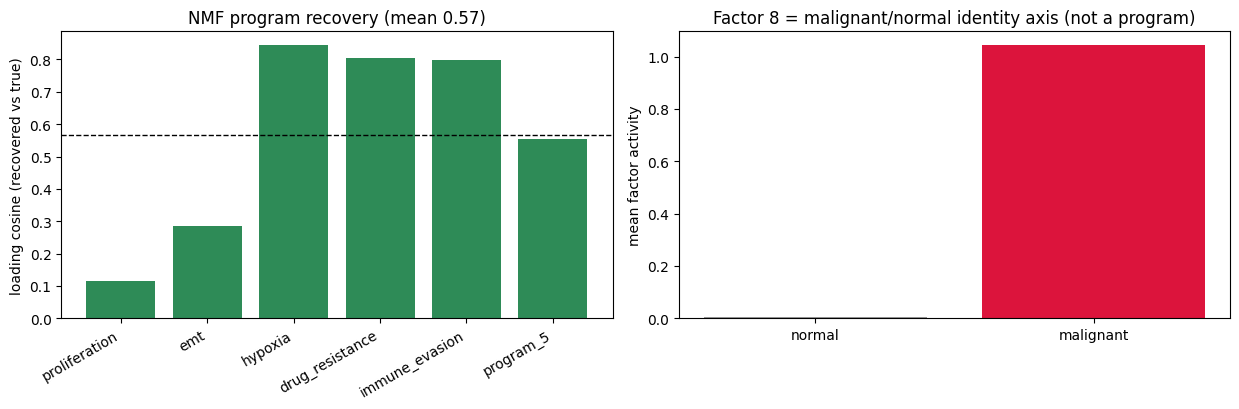

In [7]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment

# fixed-depth Poisson counts of the mixture (counts_anndata style)
E = cd["cell_exp"].values[mix_pos]
tot = E.sum(1, keepdims=True)
rate = np.divide(E, tot, out=np.zeros_like(E), where=tot > 0) * 20000
X = rng.poisson(rate).astype(float)

k_factors = K + 3
model = NMF(n_components=k_factors, init="nndsvda", random_state=0, max_iter=1000)
W = model.fit_transform(np.log1p(X))       # cells x factors (activities)
H = model.components_                       # factors x genes (loadings)

def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return 0.0 if na == 0 or nb == 0 else float(a @ b / (na * nb))

C = np.array([[cos(loading[i], H[j]) for j in range(k_factors)] for i in range(K)])
rows, colsm = linear_sum_assignment(-C)
matched_cos = np.array([C[i, j] for i, j in zip(rows, colsm)])

# which factor is the cell-type factor? the one whose activity most separates normal vs malignant
sep = np.array([abs(W[~is_mal, j].mean() - W[is_mal, j].mean()) / (W[:, j].std() + 1e-9)
                for j in range(k_factors)])
ct_factor = int(sep.argmax())
matched_factors = set(colsm.tolist())

print(f"NMF with {k_factors} factors (K={K} programs + room for cell-type/extra):")
print(f"mean loading cosine (malignant programs): {matched_cos.mean():.3f}")
print("per-program cosine:", {program_names[i]: round(C[i, j], 2) for i, j in zip(rows, colsm)})
print(f"cell-type factor = factor {ct_factor} "
      f"(matched to a program: {'yes' if ct_factor in matched_factors else 'no'}); "
      f"mean activity normal {W[~is_mal, ct_factor].mean():.2f} vs malignant {W[is_mal, ct_factor].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].bar(range(K), matched_cos, color="seagreen")
axes[0].set_xticks(range(K)); axes[0].set_xticklabels(program_names, rotation=30, ha="right")
axes[0].set_ylabel("loading cosine (recovered vs true)")
axes[0].set_title(f"NMF program recovery (mean {matched_cos.mean():.2f})")
axes[0].axhline(matched_cos.mean(), color="k", ls="--", lw=1)
axes[1].bar(["normal", "malignant"],
            [W[~is_mal, ct_factor].mean(), W[is_mal, ct_factor].mean()], color=["0.6", "crimson"])
axes[1].set_ylabel("mean factor activity")
axes[1].set_title(f"Factor {ct_factor} = malignant/normal identity axis (not a program)")
plt.tight_layout()

## What this shows

* iscc builds expression from **gene programs** (scattered, functional) plus copy-number dosage
  (contiguous, positional), and exposes the **true loadings and activities** (`program_truth`) — the
  ground truth a program-inference tool never has on real data.
* The realism is a **mixture**: a factor model must separate **cell-type identity** (normal vs
  malignant) from **within-malignant programs** — and an extra NMF factor duly absorbs the
  malignant/normal identity axis instead of a program.
* The **positional-clustering** diagnostic tells a real program (near the scattered null) from a
  copy-number segment masquerading as one (→1.0) — the confound `DESIGN_expression.md §4.2` is about.
* The NMF recovery here is a **self-contained floor**, not a tool claim: some programs recover cleanly,
  others are hard at this cell count. The production tools (scDEF's structured prior, cNMF's
  consensus) do better — and the recovery-vs-CNA-burden study is theirs to own.

**Next / see also:**
[`notebooks/assay_scrna.ipynb`](assay_scrna.ipynb) (the scRNA batch/UMI model) ·
[`notebooks/combining_scdna_scrna.ipynb`](combining_scdna_scrna.ipynb) (CN→expression dosage) ·
the full **scDEF / cNMF** recovery-vs-burden benchmark: `validation/validate_programs.py`.